# Exploratory Data Analysis

This `.ipynb` file is responsible for the exploratory data analysis of the Smart Greenhouse Monitoring System.

## Data Overview

Let's first import the necessary libraries:

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

Now, we will import the dataset.

In [52]:
df = pd.read_csv("greenhouse_crop_yields.csv")

We use the `df.head()` method to inspect first 5 rows of the dataset.

In [53]:
df.head()

,greenhouse_id,crop_type,variety,planting_date,harvest_date,days_to_maturity,avg_temperature_C,min_temperature_C,max_temperature_C,humidity_percent,co2_ppm,light_intensity_lux,photoperiod_hours,irrigation_mm,fertilizer_N_kg_ha,fertilizer_P_kg_ha,fertilizer_K_kg_ha,pest_severity,soil_pH,yield_kg_per_m2
0,1.0,Tomato,Beefsteak,2023-11-02,2024-01-08,67.0,27.6,25.8,30.6,73.6,917.0,16821.0,10.0,9.8,167.0,74.0,154.0,1.3,6.1,9.19
1,3.0,Cucumber,English,2023-11-01,2024-01-03,63.0,24.4,21.0,27.3,80.8,782.0,27483.0,10.0,9.2,174.0,82.0,126.0,3.2,6.3,7.42
2,5.0,Tomato,Beefsteak,2023-02-02,2023-04-19,76.0,23.9,20.6,26.0,76.6,821.0,30516.0,10.0,7.0,234.0,64.0,243.0,1.2,6.0,20.86
3,5.0,Tomato,Heirloom,2023-07-29,2023-10-21,84.0,26.7,25.5,29.6,76.1,710.0,43580.0,15.1,5.4,167.0,63.0,234.0,0.8,6.0,22.09
4,4.0,Cucumber,Slicing,2023-02-07,2023-04-15,67.0,24.1,22.4,26.5,69.8,921.0,22283.0,10.0,8.4,102.0,98.0,173.0,1.1,7.4,6.42


We use `df.shape` to understand number of rows and columns in the dataset.

In [54]:
df.shape

(10400, 20)

We use `df.info()` method to display number of records in each column, type of data, whether any values are missing and how much memory the dataset uses.

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   greenhouse_id        10400 non-null  float64
 1   crop_type            10400 non-null  str    
 2   variety              10400 non-null  str    
 3   planting_date        10400 non-null  str    
 4   harvest_date         10400 non-null  str    
 5   days_to_maturity     10400 non-null  float64
 6   avg_temperature_C    9858 non-null   float64
 7   min_temperature_C    9858 non-null   float64
 8   max_temperature_C    9858 non-null   float64
 9   humidity_percent     9858 non-null   float64
 10  co2_ppm              9827 non-null   float64
 11  light_intensity_lux  9858 non-null   float64
 12  photoperiod_hours    10400 non-null  float64
 13  irrigation_mm        10400 non-null  float64
 14  fertilizer_N_kg_ha   9342 non-null   float64
 15  fertilizer_P_kg_ha   9342 non-null   float64
 1

We use `df.describe().T` to display a statistical summary of the dataset.

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
greenhouse_id,10400.0,3.013077,1.417617,1.0,2.0000,3.000,4.00,5.00
days_to_maturity,10400.0,64.519327,16.392426,29.0,53.0000,65.000,77.00,100.00
avg_temperature_C,9858.0,23.421627,3.401036,10.6,21.7000,24.100,25.80,32.00
min_temperature_C,9858.0,21.529580,3.473755,8.4,19.7000,22.200,24.00,30.40
max_temperature_C,9858.0,25.306868,3.455992,12.0,23.5000,25.900,27.70,34.20
humidity_percent,9858.0,74.972327,8.582842,47.2,68.9000,75.000,81.20,100.00
co2_ppm,9827.0,799.832095,148.809930,348.0,698.0000,800.000,903.00,1200.00
light_intensity_lux,9858.0,30045.450193,8086.985394,5000.0,24016.7500,30106.500,36075.75,57094.00
photoperiod_hours,10400.0,12.457529,2.308943,9.8,10.0000,12.100,14.80,16.20
irrigation_mm,10400.0,7.003212,1.982951,1.0,5.6000,7.000,8.40,13.50


We then use `df.isnull().sum()` to return the total number of null values per column.

In [57]:
df.isnull().sum()

greenhouse_id             0
crop_type                 0
variety                   0
planting_date             0
harvest_date              0
days_to_maturity          0
avg_temperature_C       542
min_temperature_C       542
max_temperature_C       542
humidity_percent        542
co2_ppm                 573
light_intensity_lux     542
photoperiod_hours         0
irrigation_mm             0
fertilizer_N_kg_ha     1058
fertilizer_P_kg_ha     1058
fertilizer_K_kg_ha     1058
pest_severity           124
soil_pH                 302
yield_kg_per_m2           0
dtype: int64

## Data Cleaning

Let's convert `planting_date` and `harvest_date` attributes from `str` to `datetime`.

In [58]:
df['planting_date'] = pd.to_datetime(df['planting_date'])
df['harvest_date'] = pd.to_datetime(df['harvest_date'])

## Univariate Analysis

For numeric columns:

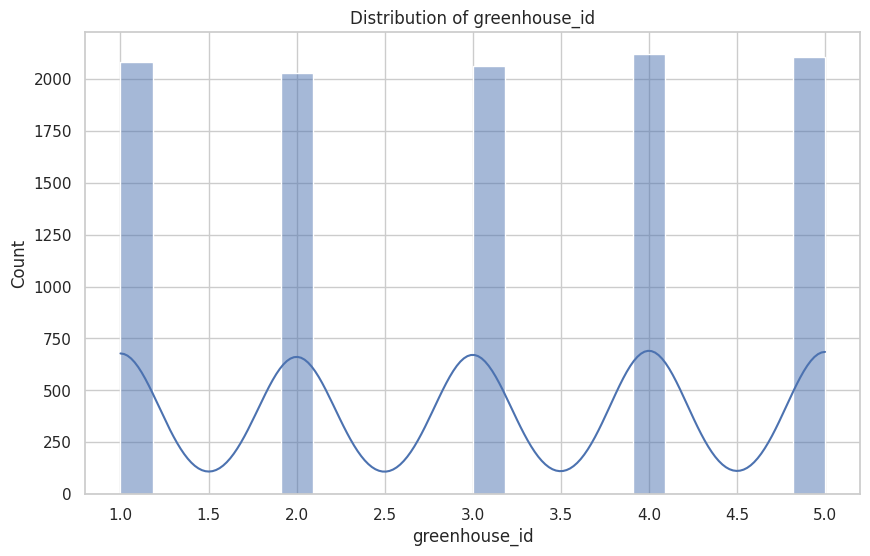

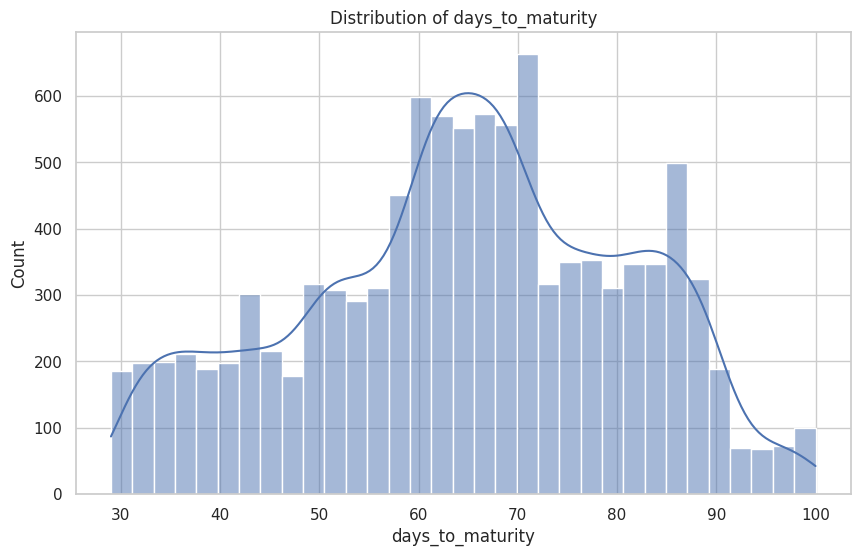

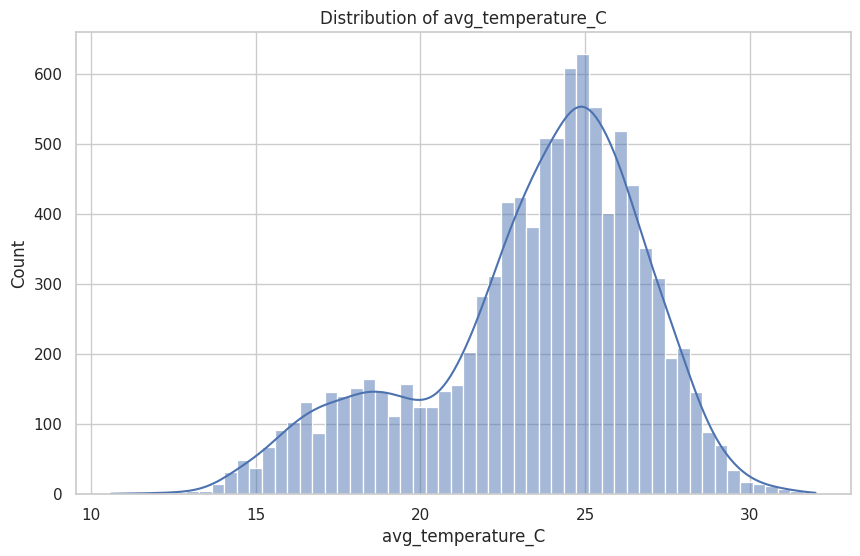

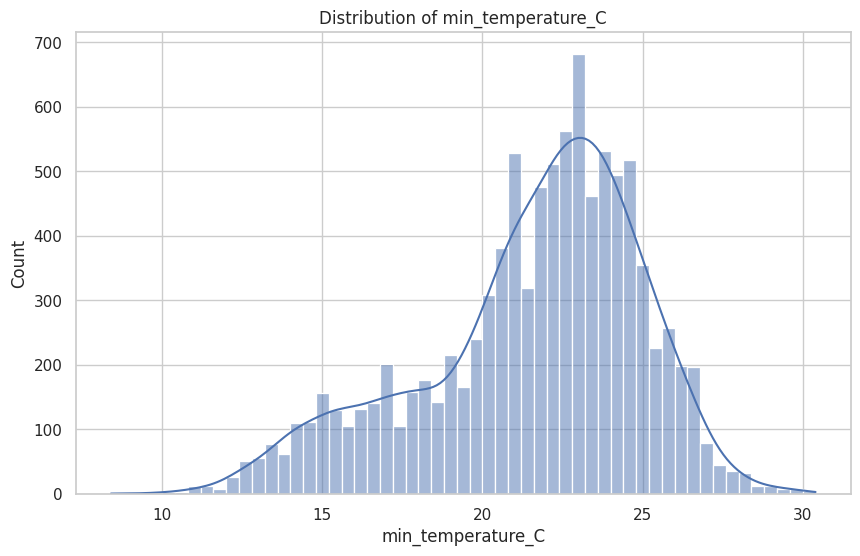

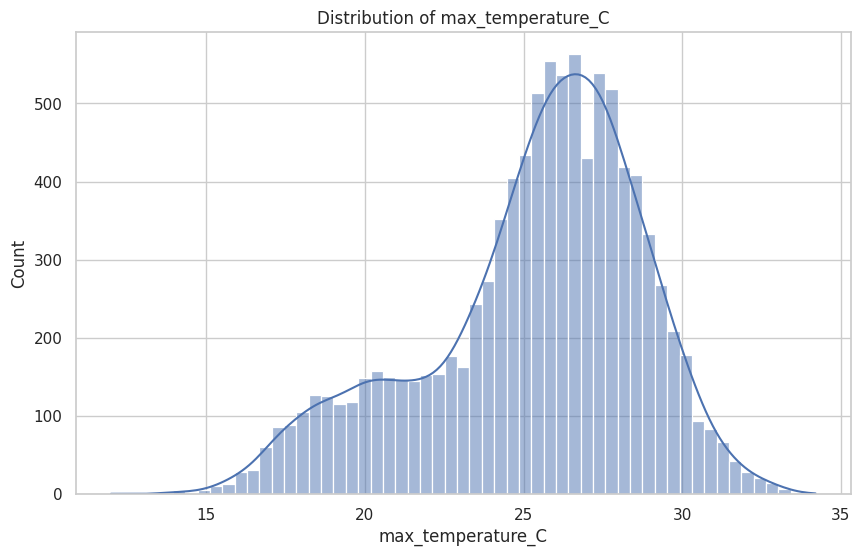

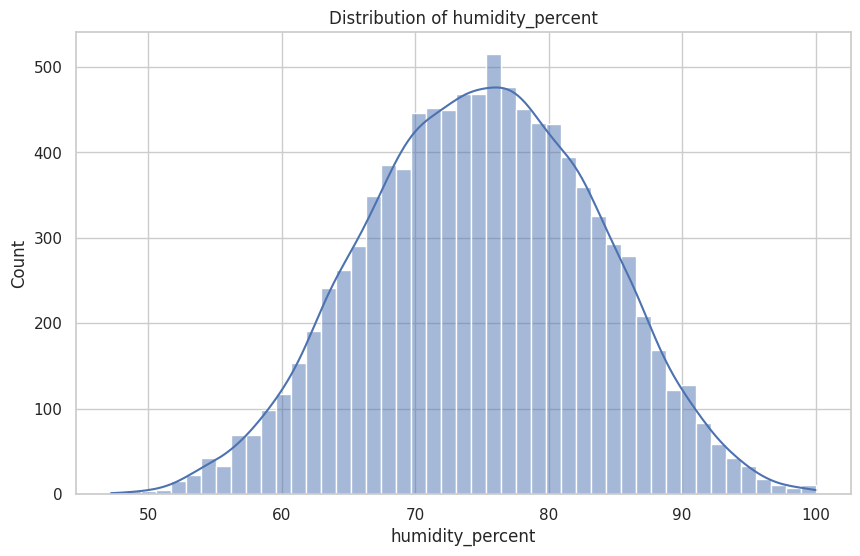

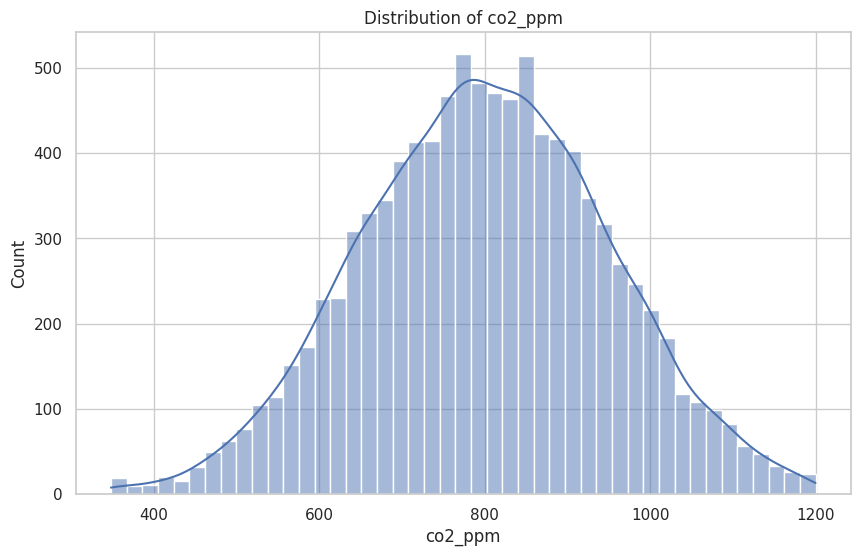

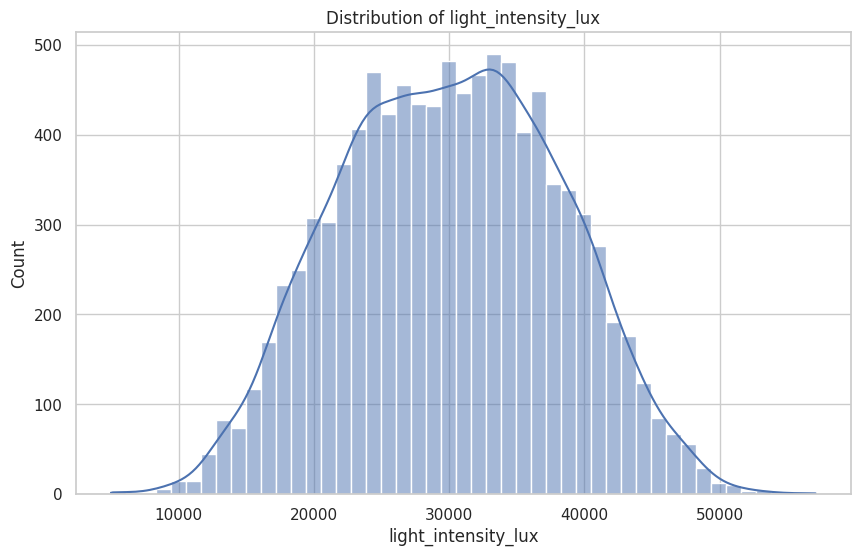

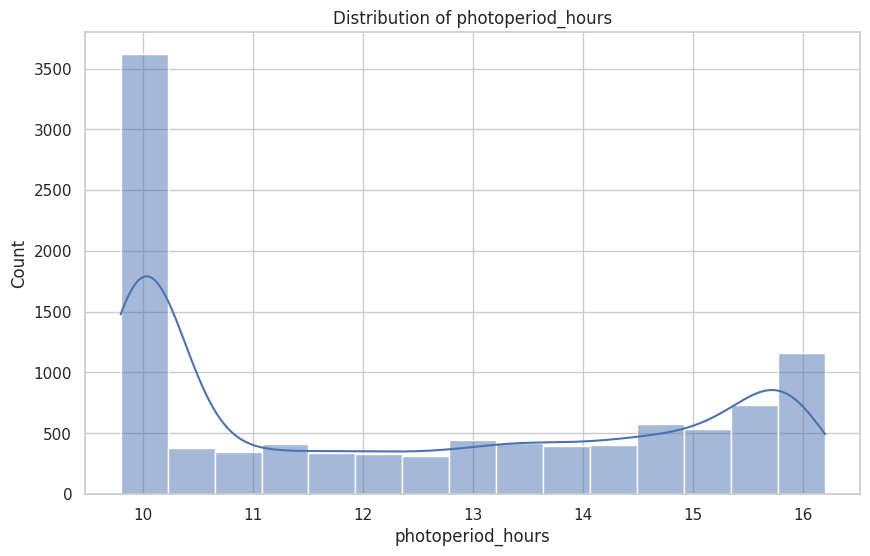

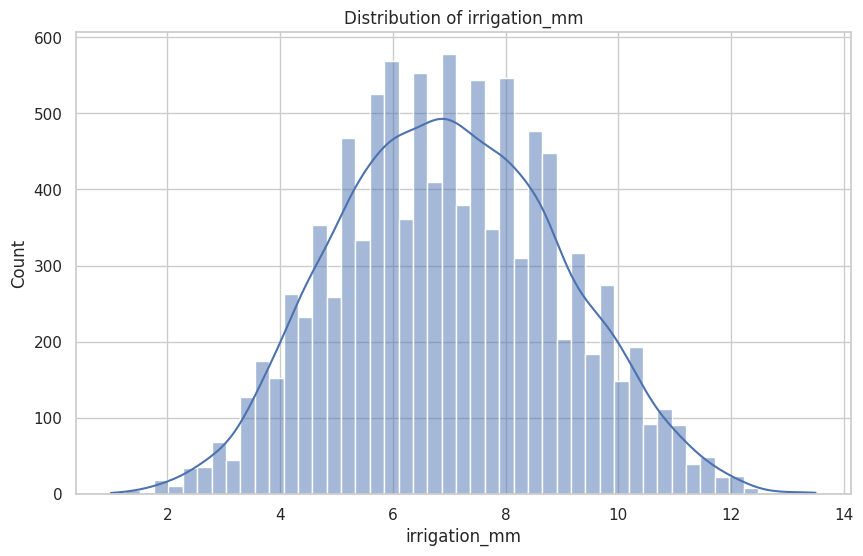

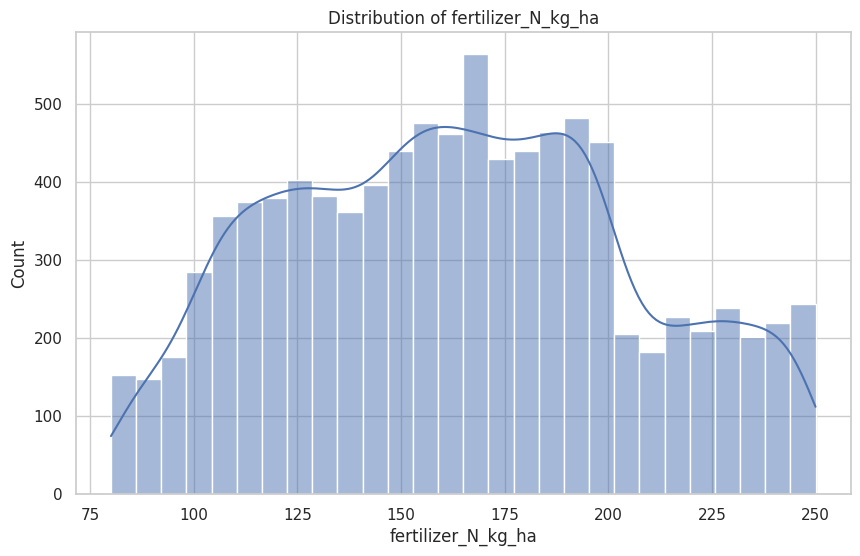

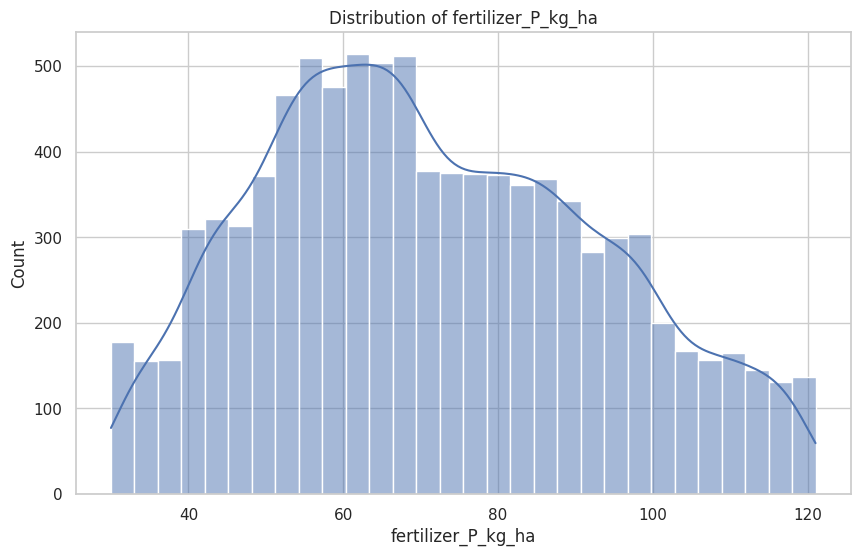

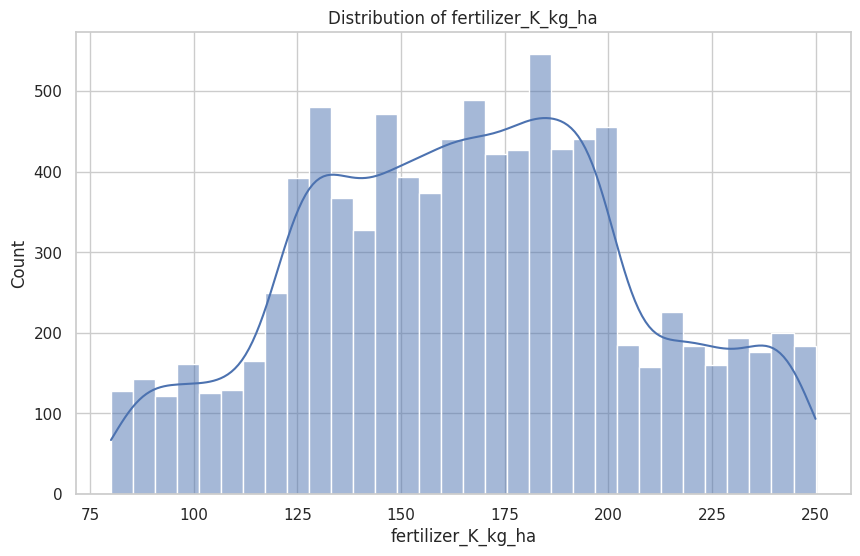

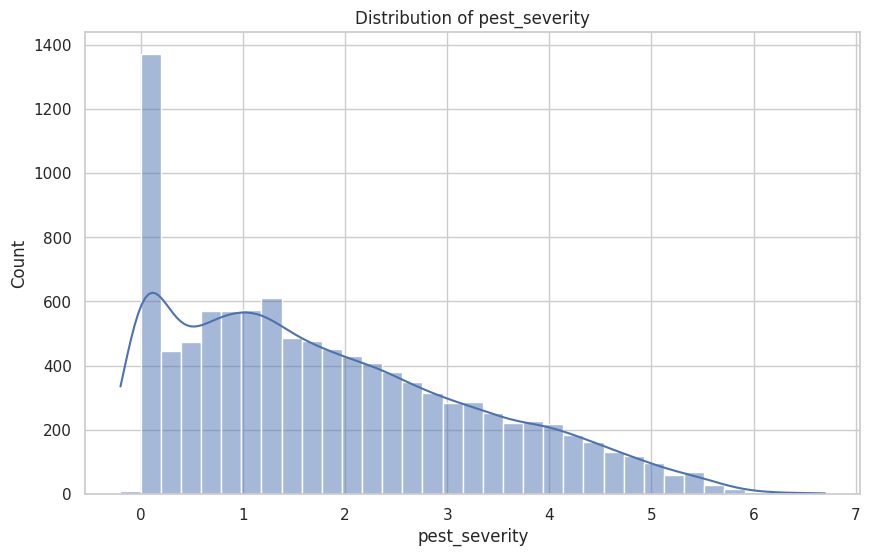

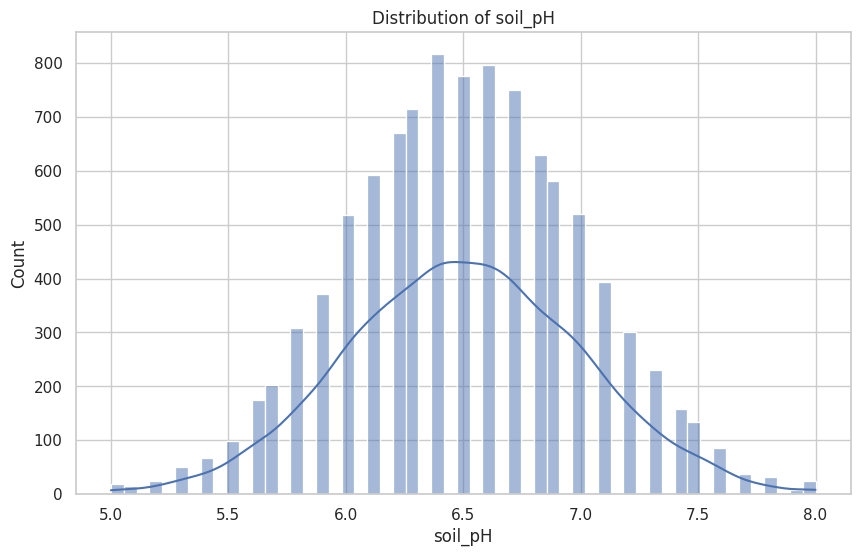

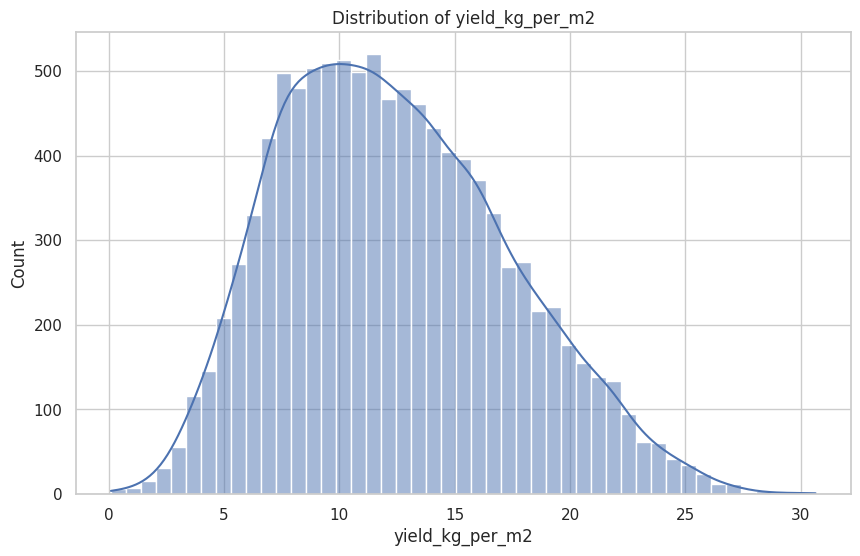

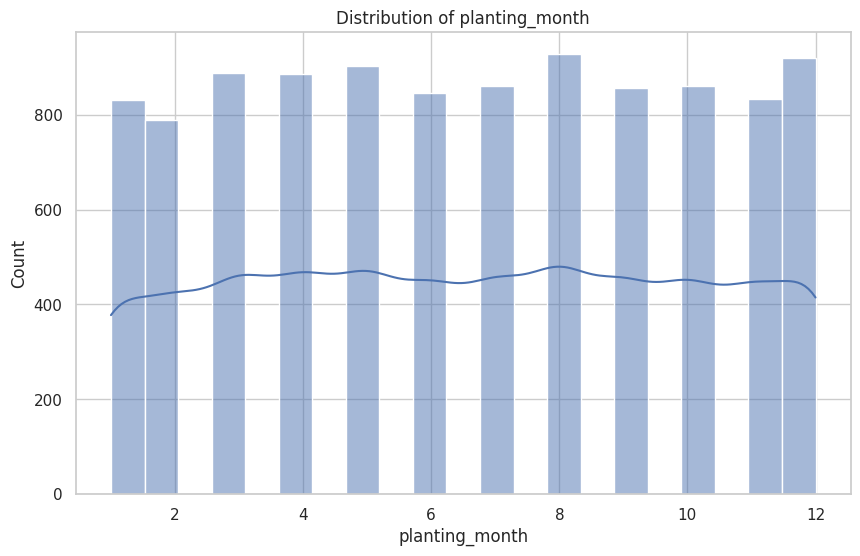

In [74]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

For categorical columns:

/tmp/ipykernel_23506/80620333.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


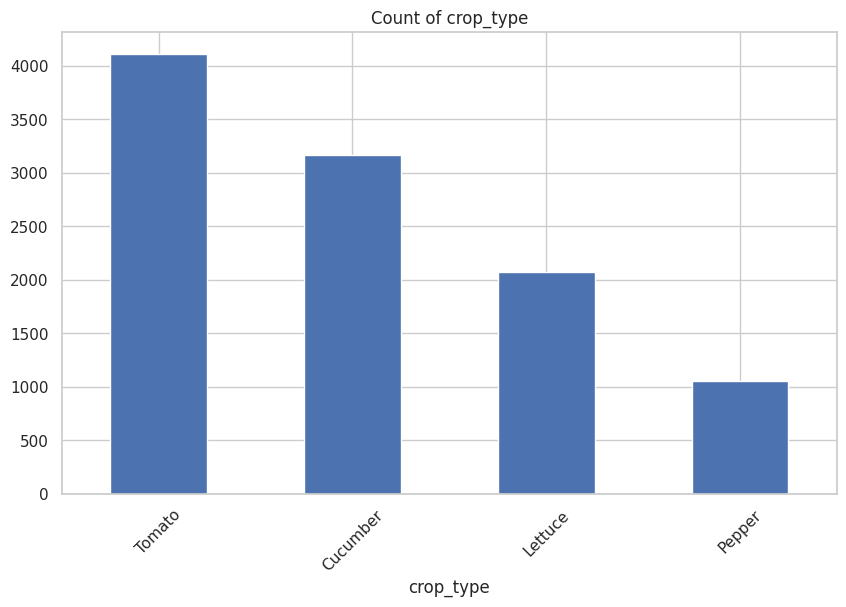

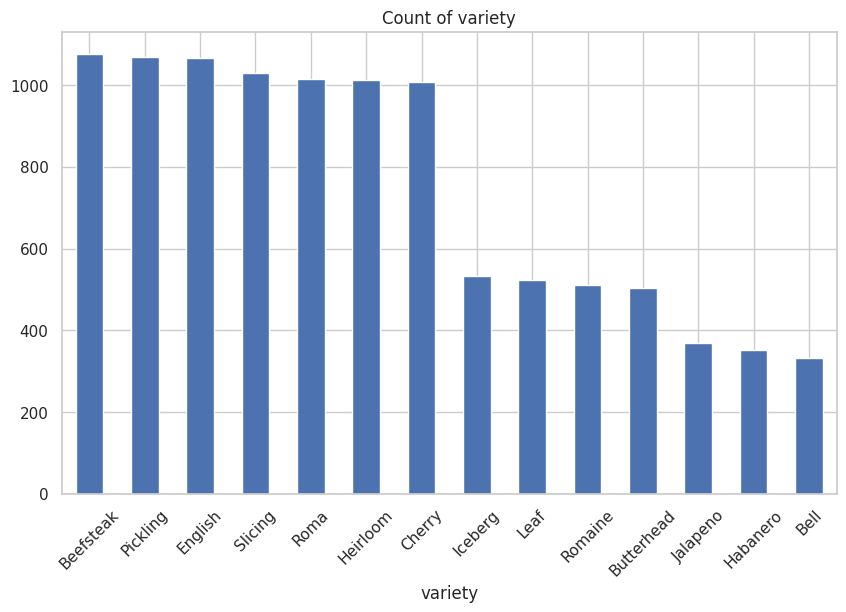

In [62]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

## Correlation Analysis

We use correlation analysis to understand the relationship among columns. 

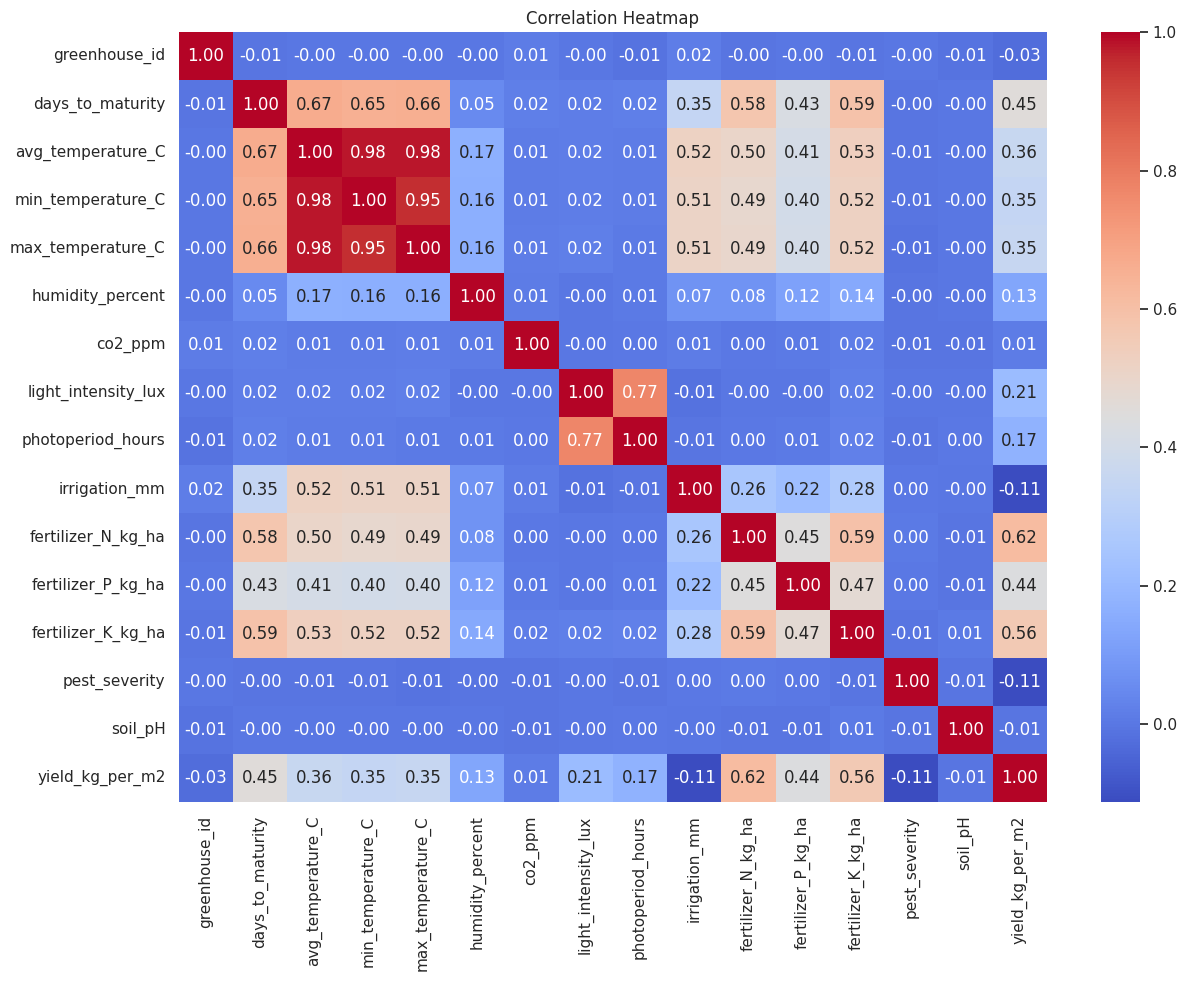

In [63]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [83]:
print("Strong correlations with yield:")
corr['yield_kg_per_m2'].sort_values(ascending=False)

Strong correlations with yield:


yield_kg_per_m2        1.000000
fertilizer_N_kg_ha     0.615576
fertilizer_K_kg_ha     0.561458
days_to_maturity       0.452976
fertilizer_P_kg_ha     0.435068
avg_temperature_C      0.356918
max_temperature_C      0.352350
min_temperature_C      0.347614
light_intensity_lux    0.211271
photoperiod_hours      0.173844
humidity_percent       0.131654
co2_ppm                0.012816
soil_pH               -0.005336
greenhouse_id         -0.026669
irrigation_mm         -0.112315
pest_severity         -0.113138
Name: yield_kg_per_m2, dtype: float64

## Target Variable Analysis

We will now analyze our target variable `yield_kg_per_m2` in depth. Let's first check the distribution of it.

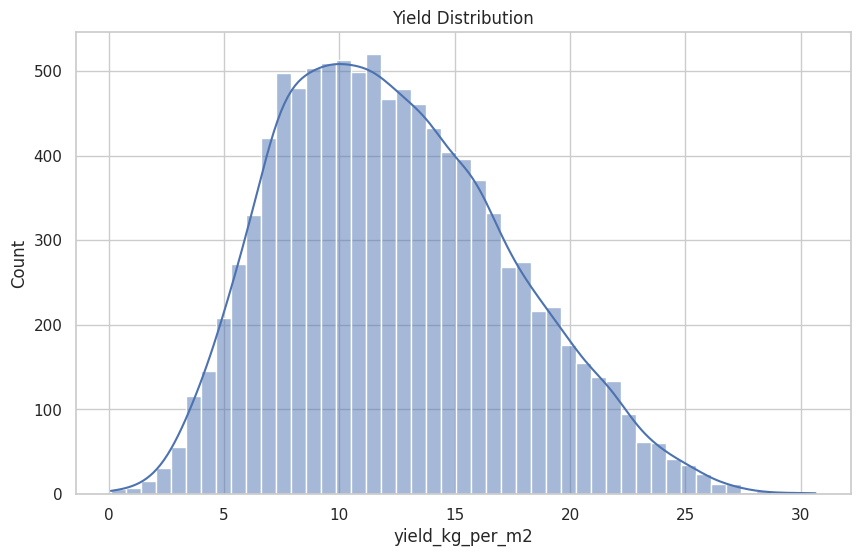

In [64]:
plt.figure()
sns.histplot(df['yield_kg_per_m2'], kde=True)
plt.title("Yield Distribution")
plt.show()

Then, let's check the yield by crop type.

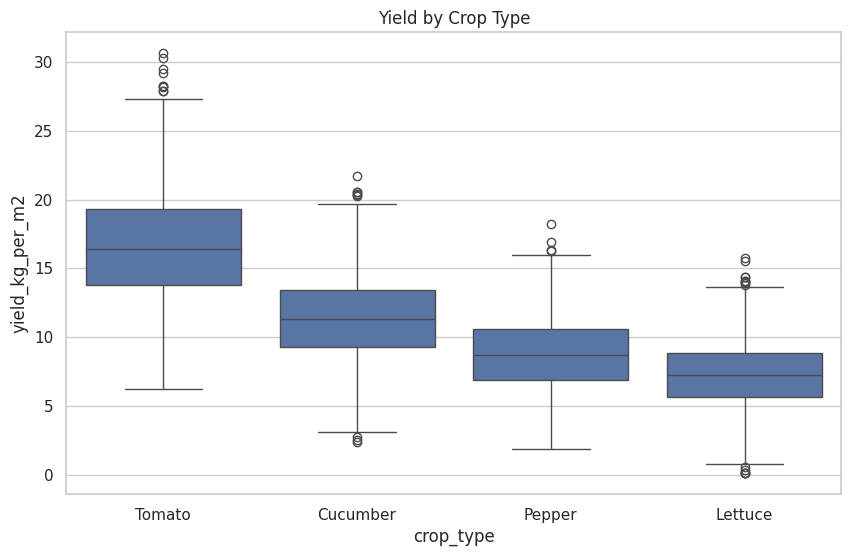

In [65]:
plt.figure()
sns.boxplot(x='crop_type', y='yield_kg_per_m2', data=df)
plt.title("Yield by Crop Type")
plt.show()

In [77]:
grouped = df.groupby('crop_type')['yield_kg_per_m2'].mean().sort_values()

print("\nAverage Yield by Crop Type:")
grouped


Average Yield by Crop Type:


crop_type
Lettuce      7.252557
Pepper       8.780399
Cucumber    11.377638
Tomato      16.657033
Name: yield_kg_per_m2, dtype: float64

Let's also check the yield by crop variety.

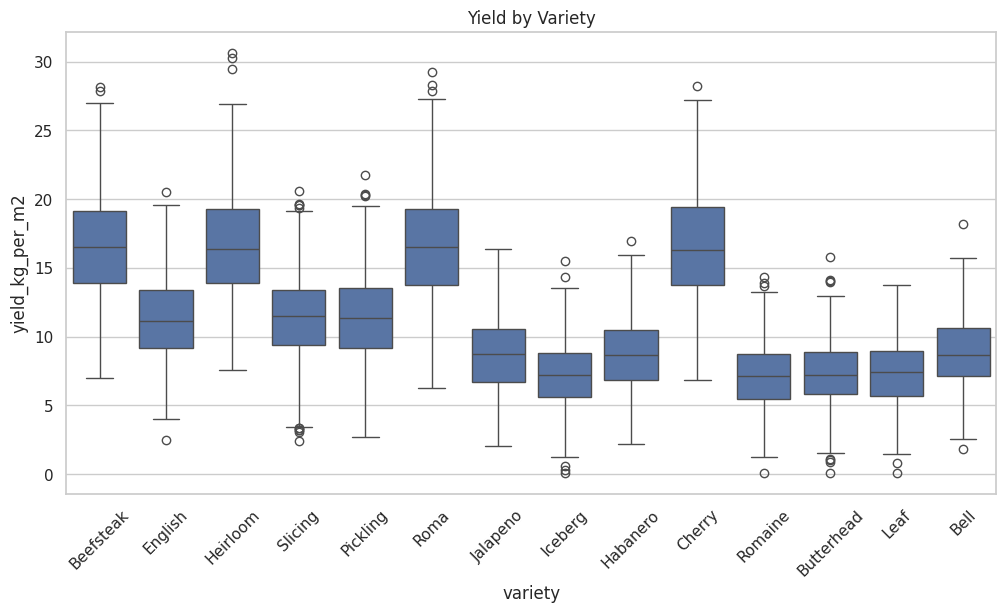

In [75]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='variety', y='yield_kg_per_m2', data=df)
plt.xticks(rotation=45)
plt.title("Yield by Variety")
plt.show()

## Feature Relationships

Let's now compare our target feature against some columns from the dataset.

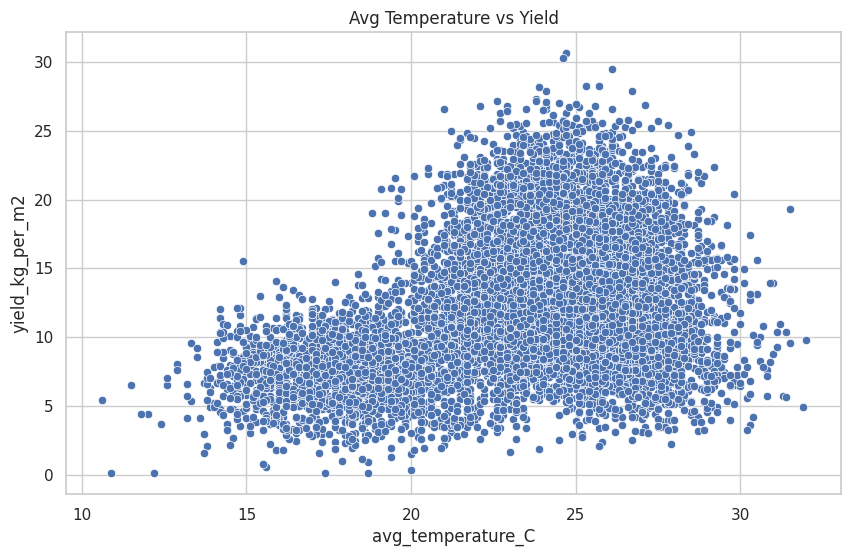

In [67]:
plt.figure()
sns.scatterplot(x='avg_temperature_C', y='yield_kg_per_m2', data=df)
plt.title("Avg Temperature vs Yield")
plt.show()

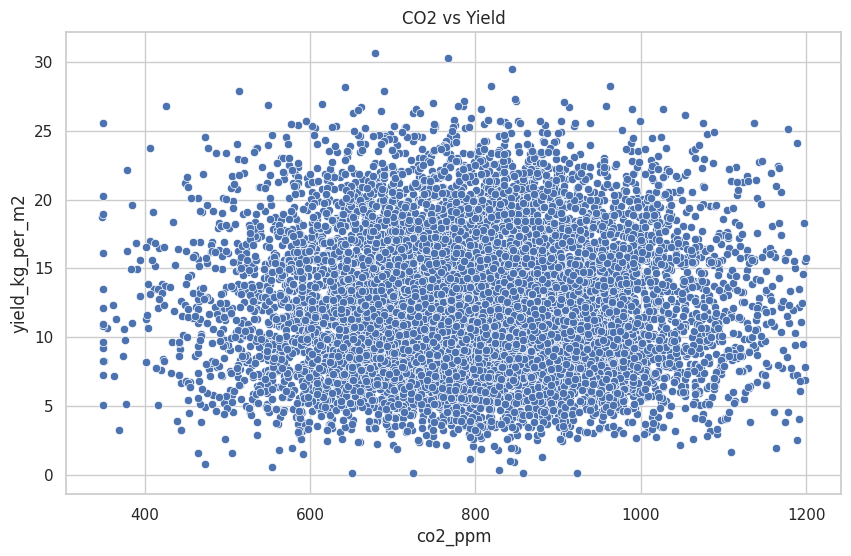

In [68]:
plt.figure()
sns.scatterplot(x='co2_ppm', y='yield_kg_per_m2', data=df)
plt.title("CO2 vs Yield")
plt.show()


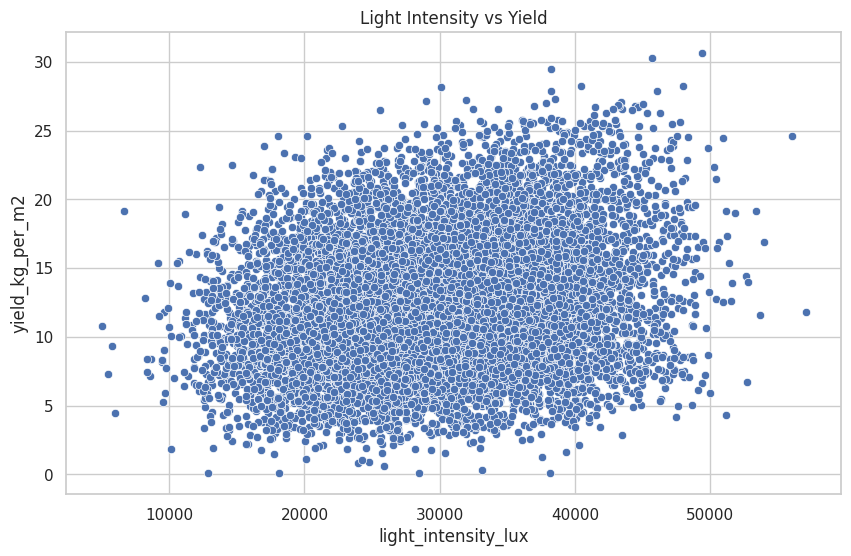

In [69]:
plt.figure()
sns.scatterplot(x='light_intensity_lux', y='yield_kg_per_m2', data=df)
plt.title("Light Intensity vs Yield")
plt.show()

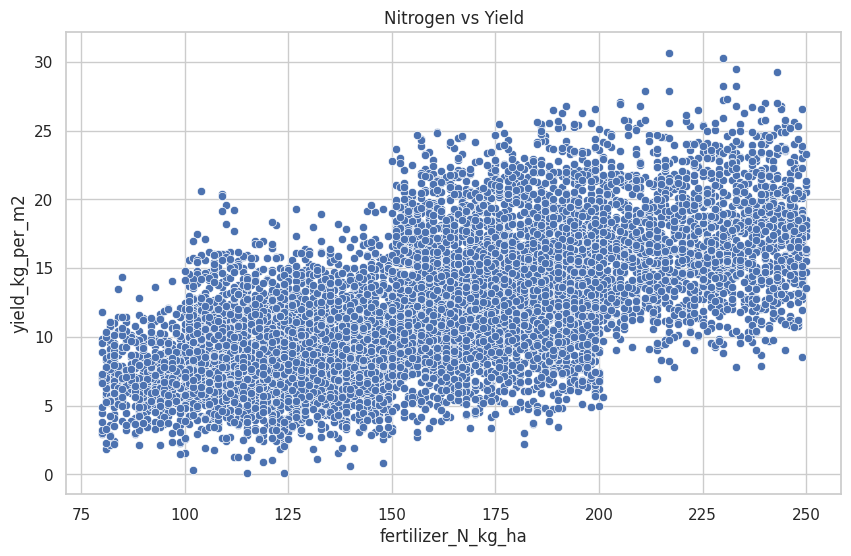

In [70]:
plt.figure()
sns.scatterplot(x='fertilizer_N_kg_ha', y='yield_kg_per_m2', data=df)
plt.title("Nitrogen vs Yield")
plt.show()

## Pairplot

Let's now use `pairplot()` to visualize pairwise relationships in our dataset.

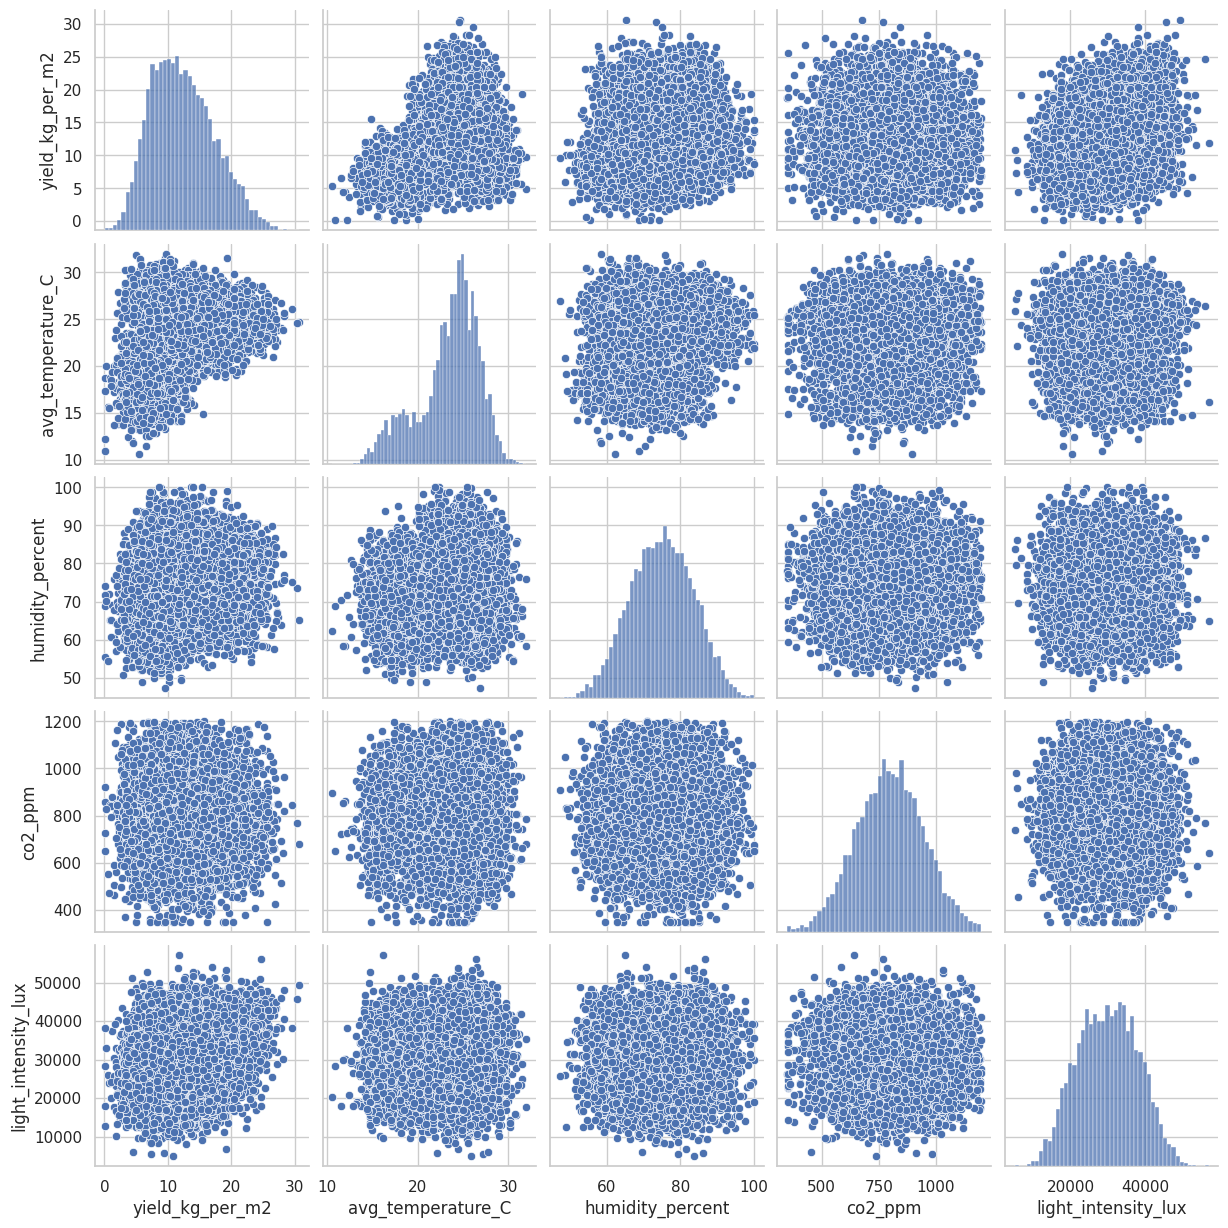

In [71]:
sns.pairplot(df[['yield_kg_per_m2',
                'avg_temperature_C',
                'humidity_percent',
                'co2_ppm',
                'light_intensity_lux']])
plt.show()

## Time-Series Analysis

Let's compare `planting_date` to our target variable `yield_kg_per_m2`.

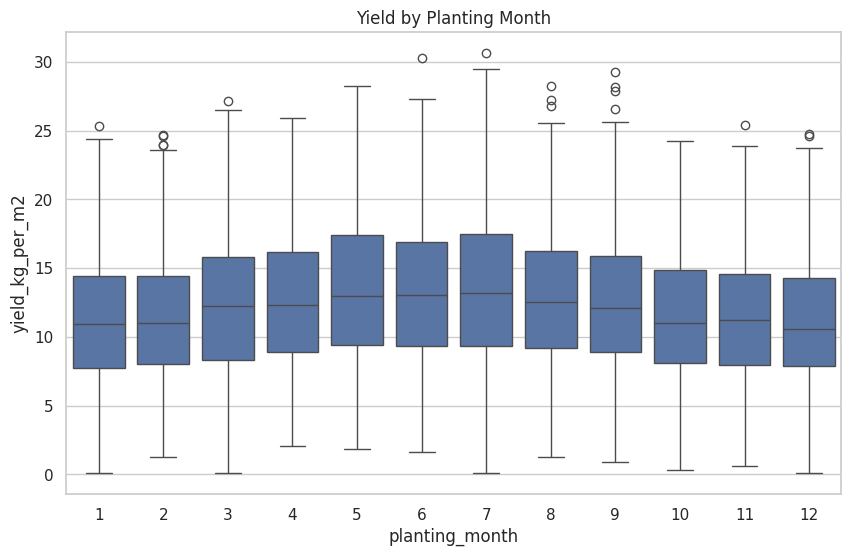

In [72]:
df['planting_month'] = df['planting_date'].dt.month

plt.figure()
sns.boxplot(x='planting_month', y='yield_kg_per_m2', data=df)
plt.title("Yield by Planting Month")
plt.show()

## Outlier Detection

For each column in our dataset, let's identify the outlier values.

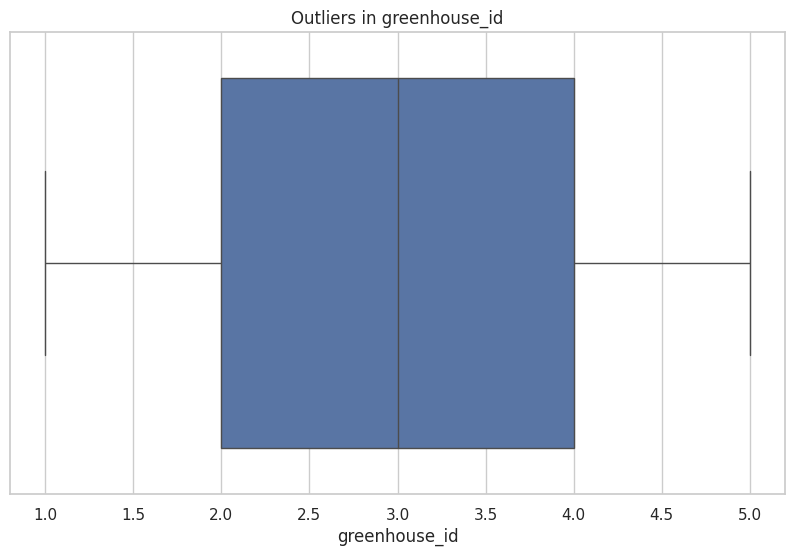

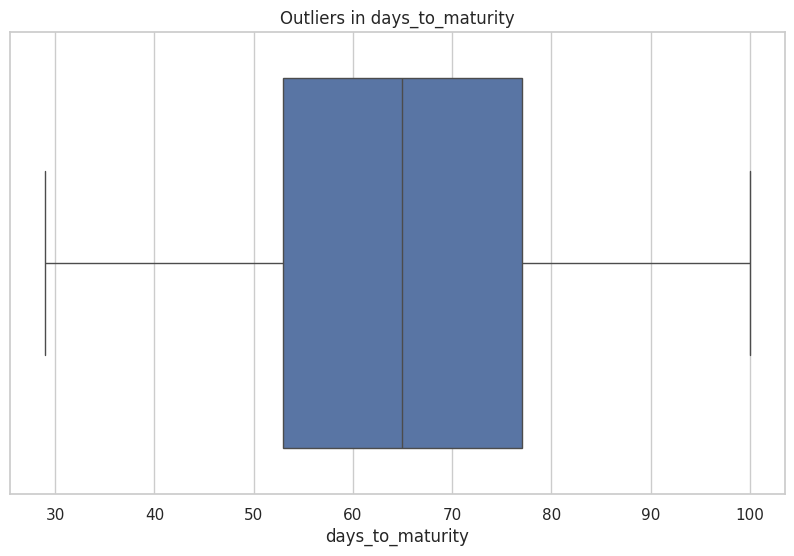

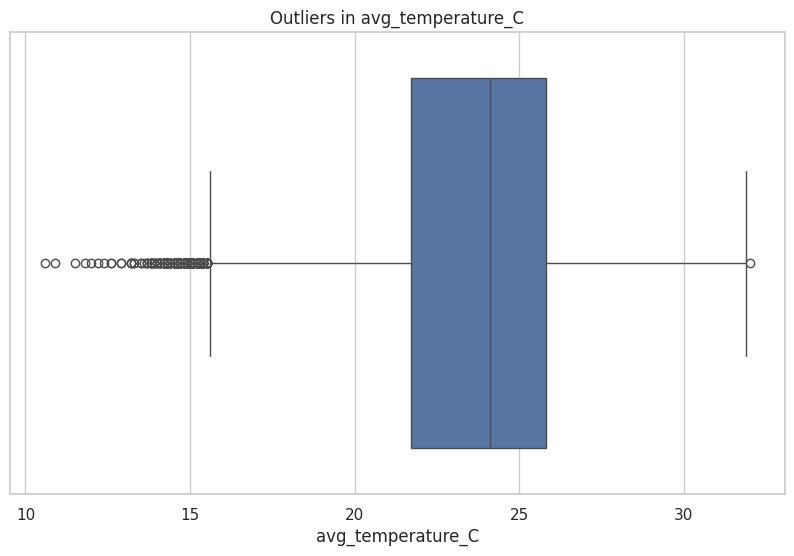

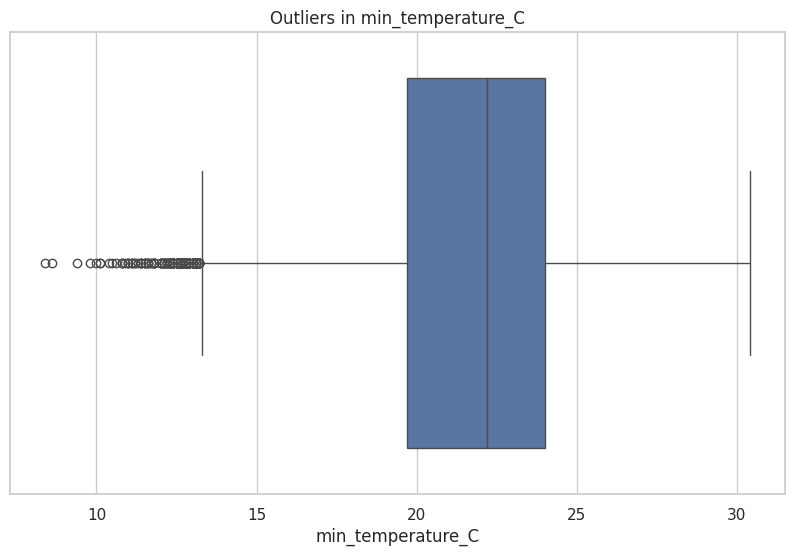

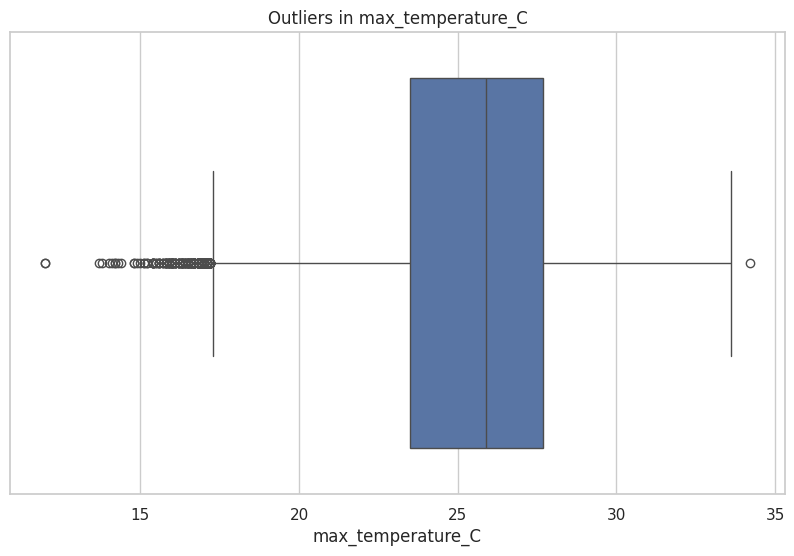

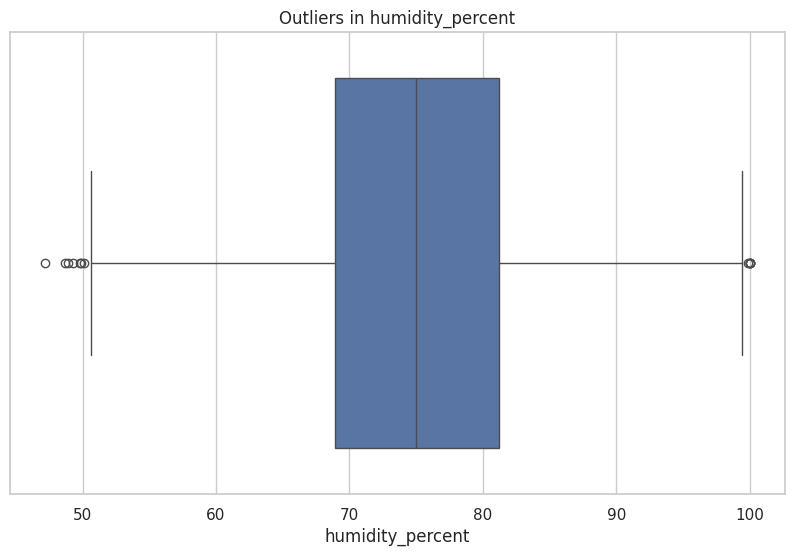

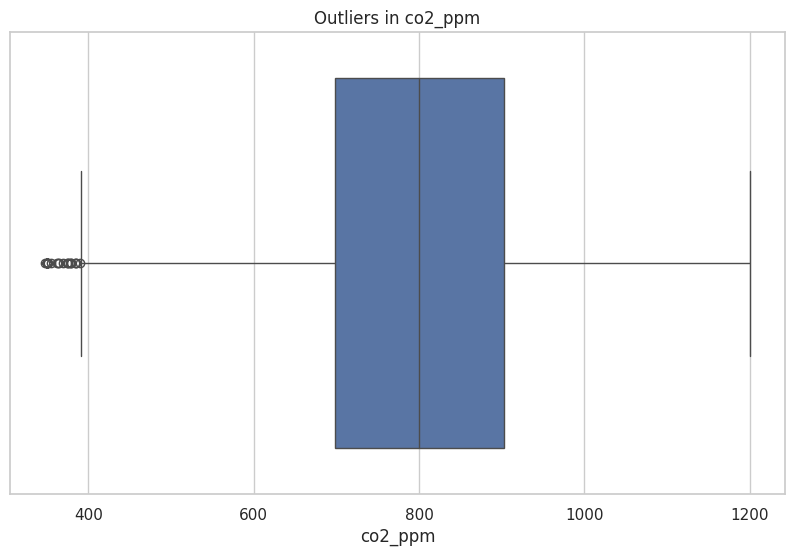

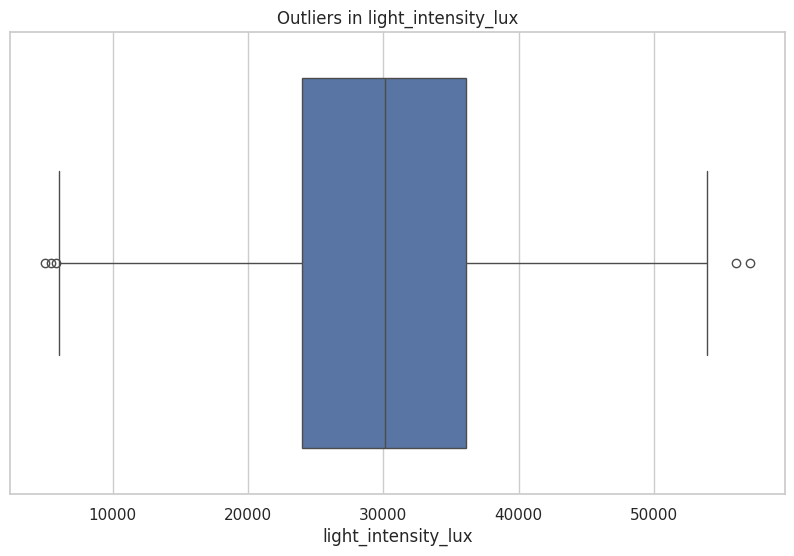

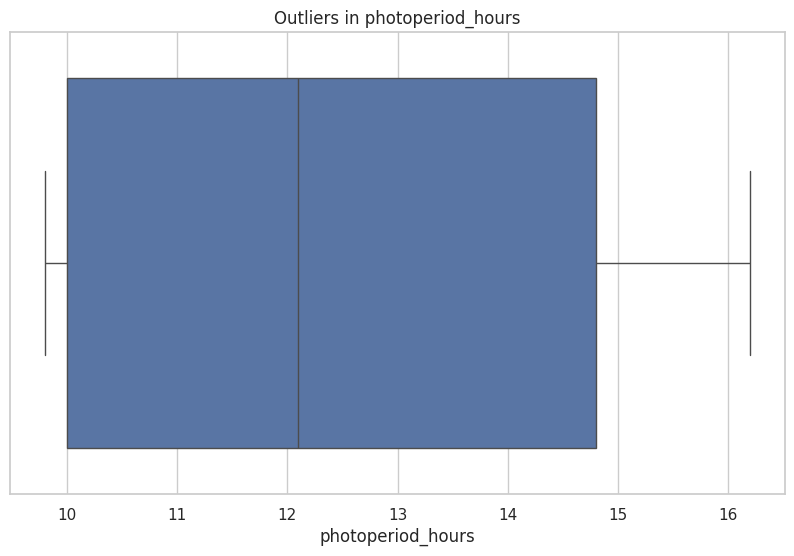

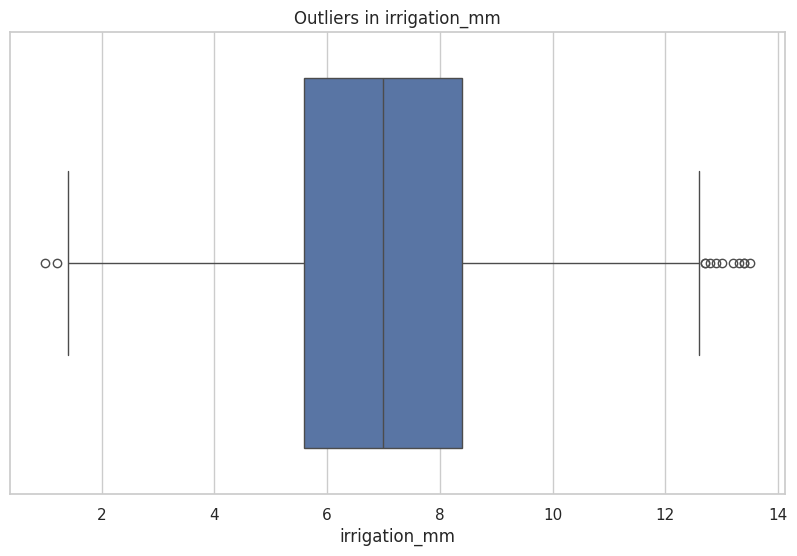

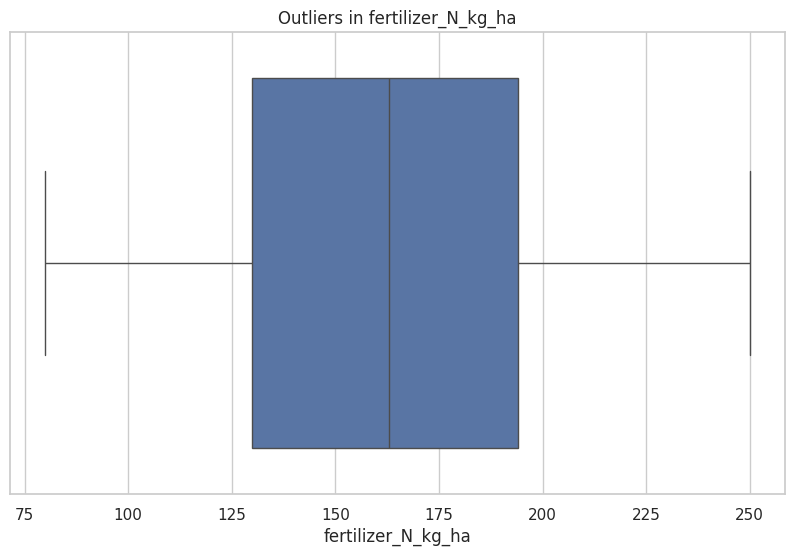

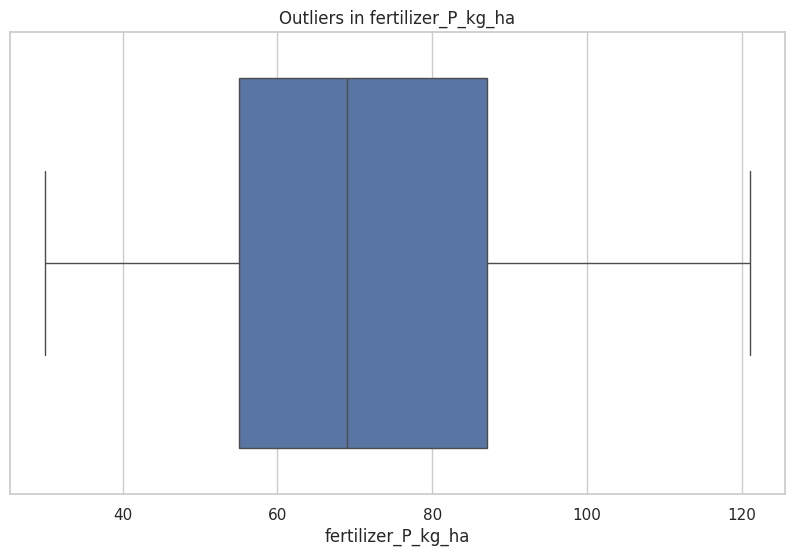

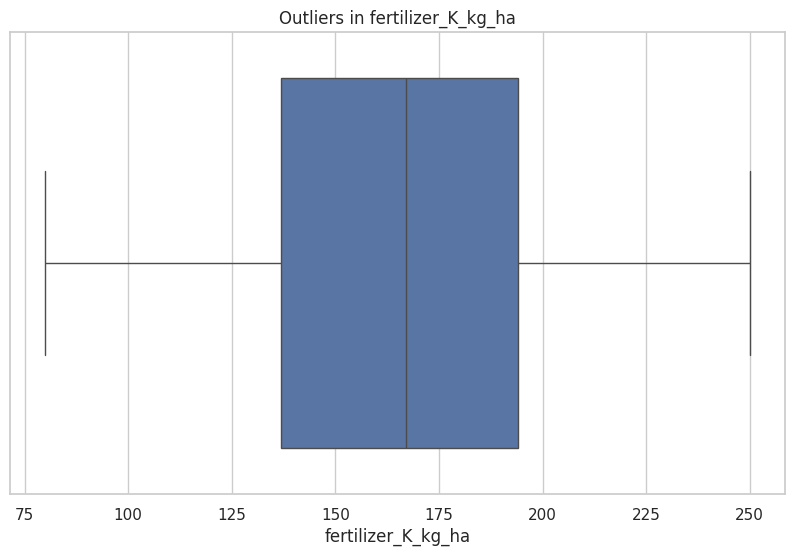

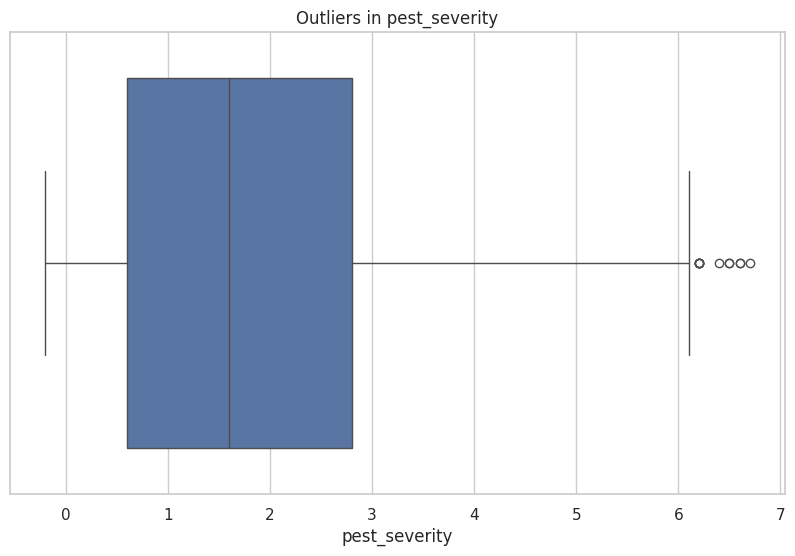

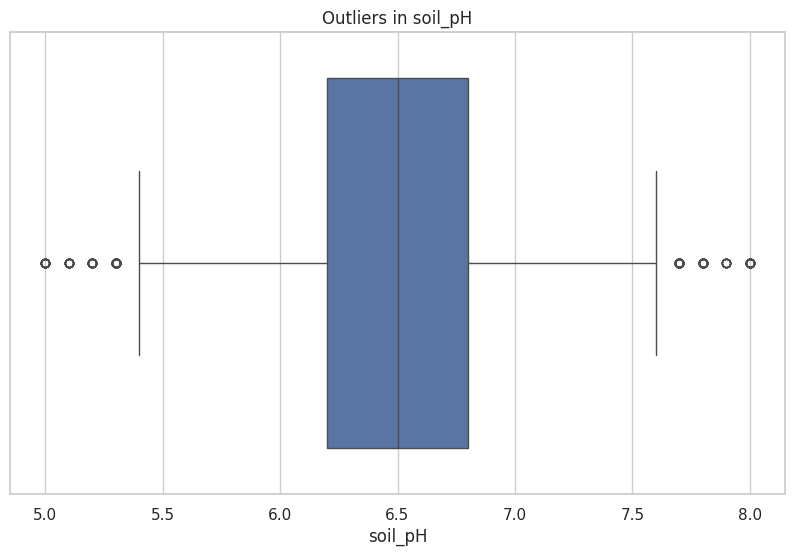

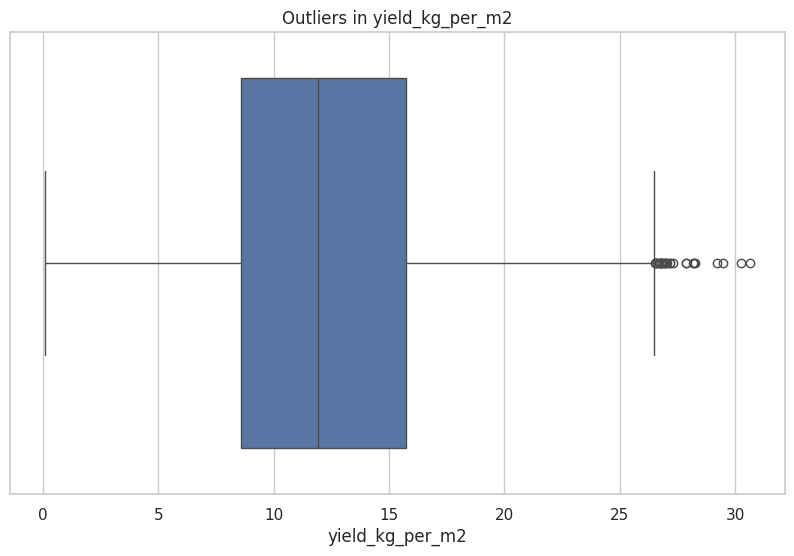

In [73]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()